# Mini-batch Training with PyTorch

In this notebook, I train a small neural network using multiple samples
and mini-batch gradient descent.

The goal is to understand:

- Multiple training samples
- Dataset and DataLoader
- Batch size
- Mini-batch training
- Training loss

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [2.0, 1.0],
    [1.0, 2.0],
    [2.0, 2.0],
    [3.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [0.0],
    [0.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0]
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([8, 2])
y shape: torch.Size([8, 1])


In [3]:
dataset = TensorDataset(X, y)

In [4]:
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [5]:
for batch_X, batch_y in dataloader:
    print("batch X:")
    print(batch_X)

    print("batch y:")
    print(batch_y)

    break

batch X:
tensor([[2., 2.],
        [2., 1.]])
batch y:
tensor([[1.],
        [1.]])


In [6]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

In [7]:
criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1
)

In [8]:
loss_history = []

for epoch in range(20):

    total_loss = 0

    for batch_X, batch_y in dataloader:

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        predictions = model(batch_X)

        # 3. Calculate loss
        loss = criterion(predictions, batch_y)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    loss_history.append(average_loss)

    print(
        "Epoch:", epoch + 1,
        "Loss:", round(average_loss, 6)
    )

Epoch: 1 Loss: 0.239962
Epoch: 2 Loss: 0.103146
Epoch: 3 Loss: 0.118348
Epoch: 4 Loss: 0.078994
Epoch: 5 Loss: 0.140177
Epoch: 6 Loss: 0.158051
Epoch: 7 Loss: 0.093447
Epoch: 8 Loss: 0.097638
Epoch: 9 Loss: 0.101257
Epoch: 10 Loss: 0.07613
Epoch: 11 Loss: 0.063013
Epoch: 12 Loss: 0.116843
Epoch: 13 Loss: 0.19221
Epoch: 14 Loss: 0.068275
Epoch: 15 Loss: 0.095273
Epoch: 16 Loss: 0.075916
Epoch: 17 Loss: 0.103544
Epoch: 18 Loss: 0.077136
Epoch: 19 Loss: 0.078786
Epoch: 20 Loss: 0.072263


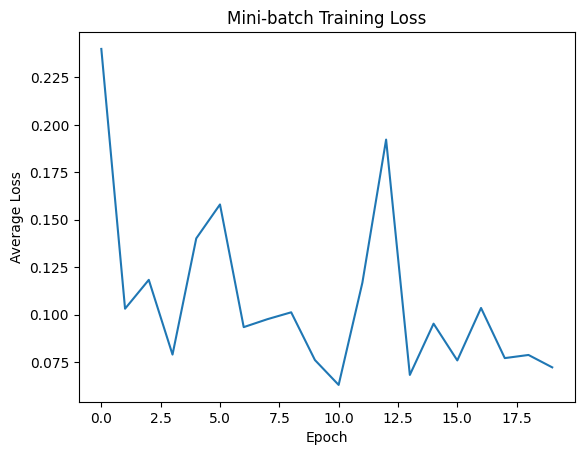

In [9]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Mini-batch Training Loss")

plt.show()

## Comparing Different Batch Sizes

Now I compare three training strategies:

- Batch size = 1: close to SGD
- Batch size = 2: mini-batch training
- Batch size = 8: full-batch training

Each model starts from the same random seed for a fair comparison.

In [10]:
def train_with_batch_size(batch_size, epochs=20):

    # Make the comparison fair
    torch.manual_seed(0)

    # Create DataLoader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Create a fresh model
    model = nn.Sequential(
        nn.Linear(2, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    )

    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    loss_history = []

    for epoch in range(epochs):

        total_loss = 0

        for batch_X, batch_y in dataloader:

            optimizer.zero_grad()

            predictions = model(batch_X)

            loss = criterion(predictions, batch_y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(dataloader)

        loss_history.append(average_loss)

    return loss_history

In [11]:
loss_bs1 = train_with_batch_size(1)
loss_bs2 = train_with_batch_size(2)
loss_bs8 = train_with_batch_size(8)

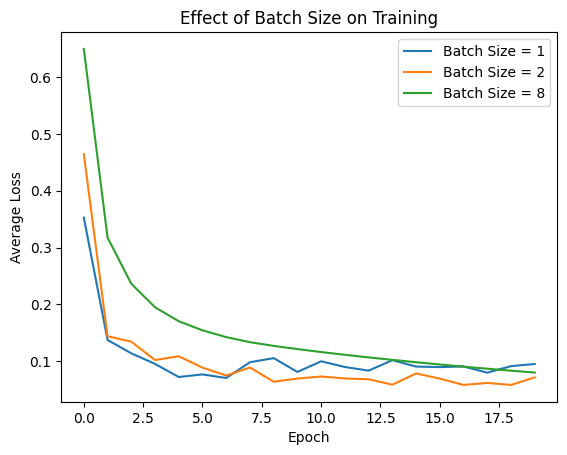

In [12]:
plt.plot(loss_bs1, label="Batch Size = 1")
plt.plot(loss_bs2, label="Batch Size = 2")
plt.plot(loss_bs8, label="Batch Size = 8")

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Effect of Batch Size on Training")

plt.legend()

plt.show()

## Conclusion

This experiment compares three different batch sizes during training.

- Batch size = 1 gives more frequent but noisier updates.
- Batch size = 2 gives a balance between speed and stability.
- Batch size = 8 produces smoother training but updates less frequently.

In this small experiment, batch size = 2 achieved the lowest final loss.

The main idea is that mini-batch training provides a practical balance
between stochastic gradient descent and full-batch gradient descent.